# Part B - Analysis

In [46]:
# Load data with features created in Part A
import pandas as pd
trader_daily_metrics = pd.read_csv("merge_df.csv")

In [47]:
df_fg = trader_daily_metrics[trader_daily_metrics['classification'].isin(['Fear','Extreme Fear','Greed','Extreme Greed'])].copy()

In [48]:
summary_fg = df_fg.groupby('classification').agg({
    'daily PnL per trader': ['mean', 'median'],
    'win rate': 'mean',
    'Avg Trade Size': 'mean',
    'Num of Trades': 'mean',
    'Long Ratio': 'mean',
    'Short Ratio': 'mean'
}).round(2)

summary_fg

daily PnL per trader         win rate Avg Trade Size  \
                               mean  median     mean           mean   
classification                                                        
Extreme Fear                4619.44  218.38     0.40        6773.46   
Extreme Greed               5161.92  418.32     0.42        5371.64   
Fear                        5328.82  107.89     0.40        8975.93   
Greed                       3318.10  158.21     0.40        6427.87   

               Num of Trades Long Ratio Short Ratio  
                        mean       mean        mean  
classification                                       
Extreme Fear          133.75       0.53        0.47  
Extreme Greed          76.03       0.47        0.53  
Fear                   98.15       0.52        0.48  
Greed                  77.63       0.47        0.53

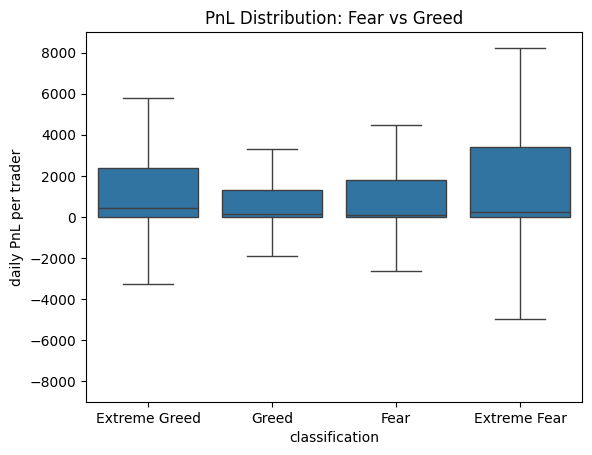

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df_fg, x='classification', y='daily PnL per trader', showfliers = False)
plt.ylim(-9000, 9000)
plt.title('PnL Distribution: Fear vs Greed')
plt.show()

Extreme Fear
- PnL is highly spread out, with both strong gains and sharp losses, showing that outcomes are more unpredictable and volatile during extreme fear.

Fear
- PnL tends to have a wider range and slightly better upside, but results are still inconsistent, with noticeable swings between profits and losses.

Greed
- PnL is more concentrated around the middle, with fewer extreme outcomes, suggesting more stable but less pronounced profits and losses.

Extreme Greed
- PnL remains fairly balanced with some positive spikes, but overall behaves similarly to other phases without a clear edge in typical profitability.


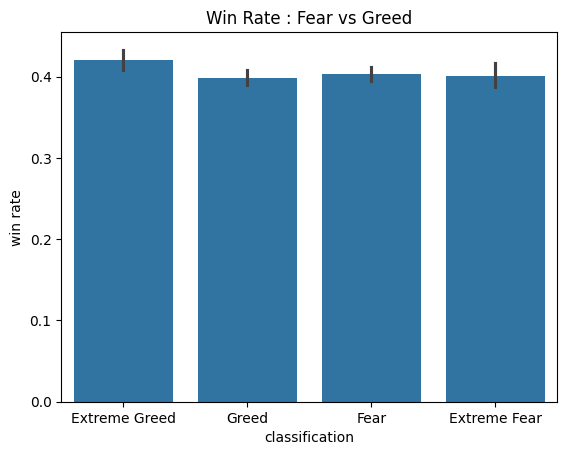

In [50]:
sns.barplot(x='classification', y='win rate', data = df_fg)
plt.title('Win Rate : Fear vs Greed')
plt.show()

The win rate remains fairly stable across all sentiment conditions,suggesting that market sentiment does not significantly impact the probability of executing profitable trades. This implies that differences in profitability, if any, are likely driven by trade size or risk-taking rather than accuracy.

In [51]:
df_fg['is_loss'] = df_fg['daily PnL per trader'] < 0
drawdown_proxy = df_fg.groupby('classification')['is_loss'].mean().reset_index()
drawdown_proxy

,classification,is_loss
0,Extreme Fear,0.193750
1,Extreme Greed,0.070342
2,Fear,0.101587
3,Greed,0.080247


# Does performance (PnL, win rate) differ between Fear vs Greed days?
Win rate remains consistent across Fear and Greed days, and median PnL shows little difference; however, Fear periods display higher PnL volatility, suggesting that performance differences are driven by risk-taking rather than improved trading accuracy.

In [52]:
behavior_summary = df_fg.groupby('classification').agg({
    'Num of Trades': 'mean',
    'Avg Trade Size': 'mean',
    'Long Ratio': 'mean',
    'Short Ratio': 'mean'
}).round(2)

behavior_summary

,Num of Trades,Avg Trade Size,Long Ratio,Short Ratio
classification,,,,
Extreme Fear,133.75,6773.46,0.53,0.47
Extreme Greed,76.03,5371.64,0.47,0.53
Fear,98.15,8975.93,0.52,0.48
Greed,77.63,6427.87,0.47,0.53


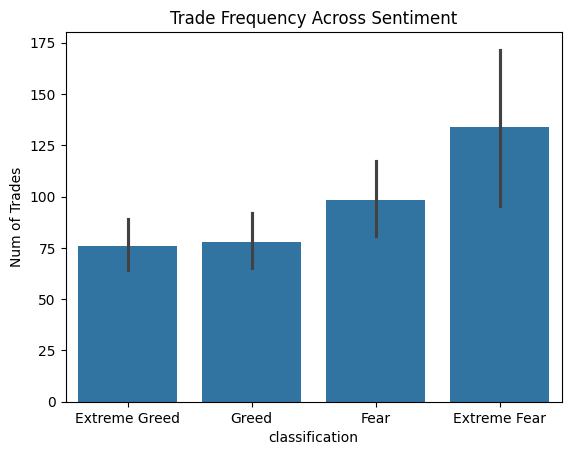

In [53]:
sns.barplot(x='classification',y='Num of Trades',data = df_fg)
plt.title('Trade Frequency Across Sentiment')
plt.show()

Trade frequency is higher during Fear and Extreme Fear, likely due to increased volatility triggering stop losses and leading to overtrading, whereas in Greed and Extreme Greed, trading activity is lower and relatively stable.

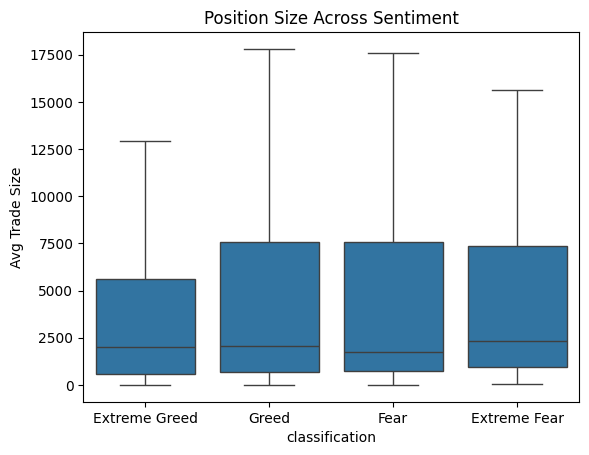

In [54]:
sns.boxplot(x='classification', y='Avg Trade Size', data=df_fg,showfliers=False)
plt.title('Position Size Across Sentiment')
plt.show()

Smaller positions in extreme greed: With sentiment strongly bullish, traders keep sizes smaller, likely because short opportunities are less attractive and upside is chased more cautiously.

Balanced sizing in other conditions: During fear, greed, and extreme fear, average trade sizes remain relatively stable, indicating more consistent capital allocation, either cautious positioning in fear or confident sizing in normal conditions.

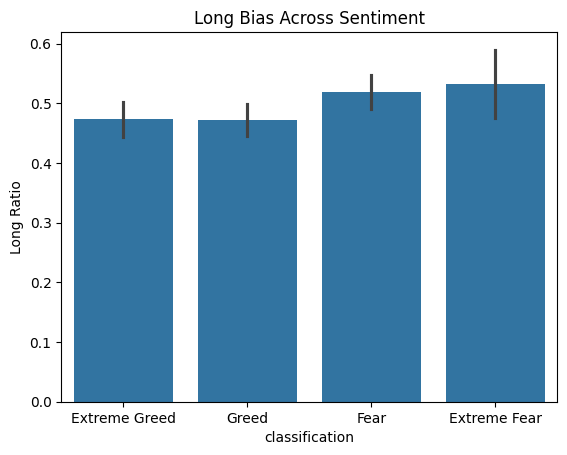

In [55]:
sns.barplot(x = 'classification', y='Long Ratio', data = df_fg)
plt.title('Long Bias Across Sentiment')
plt.show()

During Fear and Extreme Fear, traders show a stronger long bias than short, indicating they are more inclined to trade reversals (buying dips) rather than following the prevailing downward trend.

# Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
Yes,traders clearly adjust their behavior based on sentiment.

During Fear and Extreme Fear, traders become more active and show a stronger long bias, indicating a tendency to buy dips and trade reversals, often leading to higher trade frequency due to volatility and stop-loss triggers. In contrast, during Greed and Extreme Greed, trading activity stabilizes and position sizes tend to decrease, with traders participating in bullish trends more cautiously. Overall, sentiment influences how frequently traders trade, how they allocate capital, and whether they prefer long or short positions.


In [56]:
#Frequent vs Infrequent Traders

In [57]:
#Consistent vs Inconsistent Traders